# GT-centered encoder retrieval

Encoder representations are extracted from ROIs centered on ground-truth WT. This provides an oracle-localization reference for retrieval; predicted-mask localization is evaluated in notebook 08c.

In [10]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [11]:
from brats_pipeline.common import seed_all, guard_output_directory
from brats_pipeline.data import (
    jp, load_nii as _load_nii, normalize_nonzero, remap_brats_labels,
    xyz_to_dhw, dhw_to_xyz, best_tumor_slice_dhw,
)
from brats_pipeline.inference import (
    create_segresnet, load_trusted_checkpoint, extract_model_state_dict,
    predict_labels_dhw, brats_region_dice_np, brats_region_voxels,
)
load_nii = partial(_load_nii, project_root=PROJECT_ROOT)
from brats_pipeline.data import (
    canonicalize_brats_labels as remap_brats_labels,
    axis_crop_pad_retrieval as axis_crop_pad,
    crop_patch_xyz_retrieval as crop_patch_xyz,
    tumor_center_xyz_retrieval as tumor_center_xyz,
    mask_center_xyz, image_foreground_center_xyz, euclidean_center_distance,
)
from brats_pipeline.retrieval import (
    l2_normalize_np, ensure_no_nan_matrix, encode_segresnet_features,
    pool_feature_map, extract_embedding_from_patch, load_encoder, compute_neighbors,
    mask_stats, compute_tumor_phenotype_features,
    bbox_sizes, compactness_proxy, centroid_or_nan, compute_tumor_features,
)
from brats_pipeline.common import save_dataframe as _save_dataframe, safe_display, save_json
set_seed = seed_all
l2_normalize_rows = l2_normalize_np
resolve_data_path = resolve_existing_path

In [12]:


import os
import json
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

try:
    import nibabel as nib
except ImportError as e:
    raise ImportError(
        "nibabel is required to load BraTS .nii.gz files."
    ) from e

try:
    from monai.networks.nets import SegResNet
except ImportError as e:
    raise ImportError(
        "MONAI is required because checkpoints were trained with MONAI SegResNet."
    ) from e

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

warnings.filterwarnings("ignore", category=UserWarning)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA GeForce RTX 4090


## Configuration

In [13]:


PROJECT_ROOT = Path(str(PROJECT_ROOT))

CFG = {
    # Data.
    "manifest": str(PROJECT_ROOT / 'data/processed/manifest_4clients_seed42.csv'),

    # Optional cache from 02b.
    # If missing, notebook falls back to manifest['paths'] NIfTI loading.
    "use_numpy_cache_if_available": True,
    "cache_manifest": "data/processed/npy_cache_float32/cache_manifest.csv",

    # Retrieval evaluation cases.
    "split_filter": ["test"],
    "restrict_to_common_metric_patients": True,
    "max_cases": None,  # debug only, e.g. 8

    # ROI for encoder embedding extraction.
    # Ground-truth WT center used for the oracle-localization reference.
    "roi_source": "gt_wt_center",
    "patch_size": (128, 128, 128),

    # Embedding extraction.
    "embedding_method": "multiscale_gap_gmp",
    "embedding_batch_size": 1,

    # Retrieval.
    "top_k": [1, 3, 5, 10],
    "retrieval_spaces": ["embedding", "tumor_features", "hybrid"],
    "hybrid_feature_weight": 0.25,

    # Optional query cases for qualitative inspection.
    "example_query_ids": [
        "BraTS2021_01477",
        "BraTS2021_01491",
        "BraTS2021_01513",
        "BraTS2021_01527",
        "BraTS2021_01528",
        "BraTS2021_01531",
    ],

    # Outputs.
    "save_dir": "docs/08_static_digital_twin_retrieval_test",
    "overwrite_embeddings": True,

    # Models/checkpoints.
    "experiments": [
        {
            "key": "centralized_s32_cew",
            "name": "Centralized SegResNet32 final CE-weighted — TEST",
            "short_name": "Centralized-S32",
            "family": "centralized",
            "checkpoint": "models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt",
            "metrics_path": "models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "enabled": True,
            "required": True,
        },
        {
            "key": "fedavg_s32_cew",
            "name": "FedAvg SegResNet32 final CE-weighted — TEST",
            "short_name": "FedAvg-S32",
            "family": "federated",
            "checkpoint": "models/federated_fedavg_segresnet32_final/fedavg_best_mean_dice.pt",
            "metrics_path": "models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "enabled": True,
            "required": True,
        },
        {
            "key": "fedprox_s32_cew",
            "name": "FedProx SegResNet32 final CE-weighted — TEST",
            "short_name": "FedProx-S32",
            "family": "federated",
            "checkpoint": "models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt",
            "metrics_path": "models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "enabled": True,
            "required": False,
        },
    ],

    # Must match 03/05/07.
    "model_kwargs": {
        "spatial_dims": 3,
        "in_channels": 4,
        "out_channels": 4,
        "init_filters": 32,
        "blocks_down": (1, 2, 2, 4),
        "blocks_up": (1, 1, 1),
        "dropout_prob": 0.1,
    },

    # Figures and CIs.
    "make_figures": True,
    "pca_components": 2,
    "bootstrap_n": 1000,
    "bootstrap_seed": 42,
}

SAVE_DIR = PROJECT_ROOT / CFG["save_dir"]
TABLE_DIR = SAVE_DIR / "tables"
FIGURE_DIR = SAVE_DIR / "figures"
EMBED_DIR = SAVE_DIR / "embeddings"
REPORT_DIR = SAVE_DIR / "reports"
LOG_DIR = SAVE_DIR / "logs"

for d in [SAVE_DIR, TABLE_DIR, FIGURE_DIR, EMBED_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SAVE_DIR:", SAVE_DIR)
CFG

PROJECT_ROOT: /home/mandrakedrink/projects/research_ts_bs
SAVE_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test


{'manifest': '/home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv',
 'use_numpy_cache_if_available': True,
 'cache_manifest': 'data/processed/npy_cache_float32/cache_manifest.csv',
 'split_filter': ['test'],
 'restrict_to_common_metric_patients': True,
 'max_cases': None,
 'roi_source': 'gt_wt_center',
 'patch_size': (128, 128, 128),
 'embedding_method': 'multiscale_gap_gmp',
 'embedding_batch_size': 1,
 'top_k': [1, 3, 5, 10],
 'retrieval_spaces': ['embedding', 'tumor_features', 'hybrid'],
 'hybrid_feature_weight': 0.25,
 'example_query_ids': ['BraTS2021_01477',
  'BraTS2021_01491',
  'BraTS2021_01513',
  'BraTS2021_01527',
  'BraTS2021_01528',
  'BraTS2021_01531'],
 'save_dir': 'docs/08_static_digital_twin_retrieval_test',
 'overwrite_embeddings': True,
 'experiments': [{'key': 'centralized_s32_cew',
   'name': 'Centralized SegResNet32 final CE-weighted — TEST',
   'short_name': 'Centralized-S32',
   'family': 'centralized',
   'checkpoint': 'model

## Input paths

In [14]:
save_dataframe = partial(_save_dataframe, table_dir=TABLE_DIR)


In [15]:


manifest_path = resolve_existing_path(CFG["manifest"], required=True, label="manifest")
mf_df = pd.read_csv(manifest_path)

required_manifest_cols = {"patient_id", "client_domain", "split", "paths"}
missing_manifest_cols = sorted(required_manifest_cols - set(mf_df.columns))
if missing_manifest_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_manifest_cols}")

print("manifest:", manifest_path)
print("manifest shape:", mf_df.shape)
print("manifest columns:", list(mf_df.columns))

eval_df = mf_df[mf_df["split"].isin(CFG["split_filter"])].copy().reset_index(drop=True)

if CFG["max_cases"] is not None:
    eval_df = eval_df.head(int(CFG["max_cases"])).copy()

safe_display(
    "Initial eval patient counts",
    eval_df.groupby(["client_domain", "split"]).size().reset_index(name="n"),
)

manifest: /home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv
manifest shape: (1060, 4)
manifest columns: ['patient_id', 'paths', 'client_domain', 'split']


### Initial eval patient counts

,client_domain,split,n
0,TCGA-GBM,test,20
1,TCGA-LGG,test,13
2,UCSF-PDGM,test,76
3,UPENN-GBM,test,102


In [16]:
# 4.1 Resolve experiments and load full-volume metrics


enabled_experiments = []
artifact_rows = []
metrics_by_exp = {}

for exp in CFG["experiments"]:
    if not exp.get("enabled", True):
        continue

    ckpt_path = resolve_existing_path(
        exp["checkpoint"],
        required=exp.get("required", False),
        label=f"{exp['key']} checkpoint",
    )
    metrics_path = resolve_existing_path(
        exp["metrics_path"],
        required=exp.get("required", False),
        label=f"{exp['key']} full-volume metrics",
    )

    exp = dict(exp)
    exp["checkpoint_resolved"] = ckpt_path
    exp["metrics_path_resolved"] = metrics_path

    artifact_rows.append({
        "key": exp["key"],
        "name": exp["name"],
        "required": exp.get("required", False),
        "checkpoint_found": ckpt_path is not None,
        "checkpoint_resolved": str(ckpt_path) if ckpt_path is not None else None,
        "metrics_found": metrics_path is not None,
        "metrics_path_resolved": str(metrics_path) if metrics_path is not None else None,
    })

    if ckpt_path is not None and metrics_path is not None:
        enabled_experiments.append(exp)
        mdf = pd.read_csv(metrics_path)
        mdf["experiment_key"] = exp["key"]
        mdf["experiment_name"] = exp["name"]
        metrics_by_exp[exp["key"]] = mdf
        print("loaded metrics:", exp["key"], mdf.shape, metrics_path)

artifact_df = pd.DataFrame(artifact_rows)
safe_display("Resolved experiment artifacts", artifact_df, n=10)
save_dataframe(artifact_df, "01_resolved_experiment_artifacts")

if len(enabled_experiments) == 0:
    raise RuntimeError("No enabled experiment has both checkpoint and metrics.")

if CFG["restrict_to_common_metric_patients"]:
    common_ids = None
    for key, mdf in metrics_by_exp.items():
        ids = set(mdf["patient_id"].astype(str))
        common_ids = ids if common_ids is None else common_ids & ids

    common_ids = sorted(common_ids)
    before = len(eval_df)
    eval_df = eval_df[eval_df["patient_id"].astype(str).isin(common_ids)].copy().reset_index(drop=True)
    after = len(eval_df)
    print(f"restricted to common metric patient set: {before} -> {after}")

if eval_df.empty:
    raise RuntimeError("eval_df is empty after filtering.")

safe_display(
    "Final eval patient counts",
    eval_df.groupby(["client_domain", "split"]).size().reset_index(name="n"),
)
save_dataframe(eval_df[["patient_id", "client_domain", "split"]], "02_eval_patient_list")

loaded metrics: centralized_s32_cew (211, 18) /home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
loaded metrics: fedavg_s32_cew (211, 18) /home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
loaded metrics: fedprox_s32_cew (211, 18) /home/mandrakedrink/projects/research_ts_bs/models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv


### Resolved experiment artifacts

,key,name,required,checkpoint_found,checkpoint_resolved,metrics_found,metrics_path_resolved
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,True,True,/home/mandrakedrink/projects/research_ts_bs/mo...,True,/home/mandrakedrink/projects/research_ts_bs/mo...
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,True,True,/home/mandrakedrink/projects/research_ts_bs/mo...,True,/home/mandrakedrink/projects/research_ts_bs/mo...
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,False,True,/home/mandrakedrink/projects/research_ts_bs/no...,True,/home/mandrakedrink/projects/research_ts_bs/mo...


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/01_resolved_experiment_artifacts.csv
restricted to common metric patient set: 211 -> 211


### Final eval patient counts

,client_domain,split,n
0,TCGA-GBM,test,20
1,TCGA-LGG,test,13
2,UCSF-PDGM,test,76
3,UPENN-GBM,test,102


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/02_eval_patient_list.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/02_eval_patient_list.csv')

In [17]:


def load_case_from_manifest(row, normalize=True, remap=True):
    """Load one case from the manifest paths."""
    p = jp(row["paths"])

    images = []
    for m in ["t1", "t1ce", "t2", "flair"]:
        if m not in p:
            raise KeyError(f"{row['patient_id']} paths missing modality: {m}")

        vol_path = resolve_data_path(p[m], required=True, label=f"{row['patient_id']} {m}")
        vol = load_nii(vol_path, dtype=np.float32)

        if normalize:
            vol = normalize_nonzero(vol)

        images.append(vol)

    image_xyz = np.stack(images, axis=0).astype(np.float32)

    seg_path = resolve_data_path(p["seg"], required=True, label=f"{row['patient_id']} seg")
    seg_xyz = load_nii(seg_path, dtype=np.uint8)

    if remap:
        seg_xyz = remap_brats_labels(seg_xyz)

    return {
        "image_xyz": image_xyz,
        "seg_xyz": seg_xyz.astype(np.uint8),
        "patient_id": str(row["patient_id"]),
        "client_domain": row["client_domain"],
        "split": row["split"],
        "source": "manifest_nifti",
    }

## Optional NumPy cache

The cache contains preprocessed CXYZ float32 arrays. If it is unavailable, cases are loaded from the manifest NIfTI paths.

In [18]:


def find_cache_paths_for_row(cache_row):
    """Resolve cached image and segmentation arrays for one manifest row."""
    image_cols = ["image_xyz_path", "image_path", "image_npy", "image_xyz", "image_file"]
    seg_cols = ["seg_xyz_path", "seg_path", "seg_npy", "seg_xyz", "mask_path", "mask_npy"]
    dir_cols = ["case_dir", "cache_dir", "output_dir", "save_dir", "path", "case_path"]

    image_path = None
    seg_path = None

    for col in image_cols:
        if col in cache_row and pd.notna(cache_row[col]):
            image_path = Path(str(cache_row[col]))
            break

    for col in seg_cols:
        if col in cache_row and pd.notna(cache_row[col]):
            seg_path = Path(str(cache_row[col]))
            break

    if image_path is None or seg_path is None:
        case_dir = None
        for col in dir_cols:
            if col in cache_row and pd.notna(cache_row[col]):
                case_dir = Path(str(cache_row[col]))
                break

        if case_dir is not None:
            if image_path is None:
                image_path = case_dir / "image_xyz.npy"
            if seg_path is None:
                seg_path = case_dir / "seg_xyz.npy"

    if image_path is not None and not image_path.is_absolute():
        image_path = resolve_existing_path(image_path, required=False, label="cache image")

    if seg_path is not None and not seg_path.is_absolute():
        seg_path = resolve_existing_path(seg_path, required=False, label="cache seg")

    return image_path, seg_path


cache_df = None
cache_by_pid = {}

if CFG["use_numpy_cache_if_available"]:
    cache_manifest_path = resolve_existing_path(
        CFG["cache_manifest"],
        required=False,
        label="numpy cache manifest",
    )

    if cache_manifest_path is not None:
        cache_df = pd.read_csv(cache_manifest_path)
        if "patient_id" in cache_df.columns:
            cache_by_pid = {str(r["patient_id"]): r for _, r in cache_df.iterrows()}
            print("cache manifest:", cache_manifest_path)
            print("cache_df shape:", cache_df.shape)
        else:
            print("cache manifest found but has no patient_id column. Ignoring cache.")
            cache_df = None
    else:
        print("numpy cache manifest not found. Will load NIfTI from manifest.")
else:
    print("numpy cache disabled.")


def load_case_auto(row, normalize=True, remap=True):
    """Load from the NumPy cache when available, otherwise from NIfTI paths."""
    patient_id = str(row["patient_id"])

    if cache_df is not None and patient_id in cache_by_pid:
        cache_row = cache_by_pid[patient_id]
        image_path, seg_path = find_cache_paths_for_row(cache_row)

        if image_path is not None and seg_path is not None and Path(image_path).exists() and Path(seg_path).exists():
            image_xyz = np.load(image_path).astype(np.float32)
            seg_xyz = np.load(seg_path).astype(np.uint8)

            if remap:
                seg_xyz = remap_brats_labels(seg_xyz)

            return {
                "image_xyz": image_xyz,
                "seg_xyz": seg_xyz,
                "patient_id": patient_id,
                "client_domain": row["client_domain"],
                "split": row["split"],
                "source": "npy_cache",
            }

    return load_case_from_manifest(row, normalize=normalize, remap=remap)

numpy cache manifest not found. Will load NIfTI from manifest.


## Reference phenotype features

This analysis uses full-array volume fractions with normalized centroids and bounding boxes. Notebook 08c uses foreground-relative fractions and voxel-coordinate features, so the two phenotype-distance scales are not interchangeable.

In [19]:
from pathlib import Path

matches = list(
    Path("/media/mandrakedrink/DATA_DL").rglob(
        "BraTS2021_00003_t1.nii.gz"
    )
)

print("found:", len(matches))
for p in matches:
    print(p)

found: 1
/media/mandrakedrink/DATA_DL/proj1/PKG - RSNA-ASNR-MICCAI-BraTS-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet/UCSF-PDGM/BraTS2021_00003/BraTS2021_00003_t1.nii.gz


In [20]:


feature_rows = []
roi_rows = []

for i, row in eval_df.iterrows():
    case = load_case_auto(row, normalize=True, remap=True)
    seg_xyz = case["seg_xyz"]
    center_xyz = tumor_center_xyz(seg_xyz, region="WT")

    features = compute_tumor_phenotype_features(seg_xyz)
    features.update({
        "patient_id": case["patient_id"],
        "client_domain": case["client_domain"],
        "split": case["split"],
        "roi_center_x": center_xyz[0],
        "roi_center_y": center_xyz[1],
        "roi_center_z": center_xyz[2],
        "load_source": case["source"],
    })
    feature_rows.append(features)

    roi_rows.append({
        "patient_id": case["patient_id"],
        "center_x": center_xyz[0],
        "center_y": center_xyz[1],
        "center_z": center_xyz[2],
        "load_source": case["source"],
    })

    if (i + 1) % 10 == 0 or (i + 1) == len(eval_df):
        print(f"features [{i+1}/{len(eval_df)}] {case['patient_id']} source={case['source']}")

features_df = pd.DataFrame(feature_rows)
roi_df = pd.DataFrame(roi_rows)

safe_display("Tumor phenotype features", features_df, n=5)
save_dataframe(features_df, "03_patient_tumor_phenotype_features")
save_dataframe(roi_df, "04_patient_roi_centers")

features [10/211] BraTS2021_00064 source=manifest_nifti
features [20/211] BraTS2021_00144 source=manifest_nifti
features [30/211] BraTS2021_00222 source=manifest_nifti
features [40/211] BraTS2021_00292 source=manifest_nifti
features [50/211] BraTS2021_00334 source=manifest_nifti
features [60/211] BraTS2021_00399 source=manifest_nifti
features [70/211] BraTS2021_00470 source=manifest_nifti
features [80/211] BraTS2021_00499 source=manifest_nifti
features [90/211] BraTS2021_00615 source=manifest_nifti
features [100/211] BraTS2021_00663 source=manifest_nifti
features [110/211] BraTS2021_00753 source=manifest_nifti
features [120/211] BraTS2021_01005 source=manifest_nifti
features [130/211] BraTS2021_01080 source=manifest_nifti
features [140/211] BraTS2021_01131 source=manifest_nifti
features [150/211] BraTS2021_01209 source=manifest_nifti
features [160/211] BraTS2021_01277 source=manifest_nifti
features [170/211] BraTS2021_01357 source=manifest_nifti
features [180/211] BraTS2021_01453 sourc

### Tumor phenotype features

,volume_total_vox,shape_x,shape_y,shape_z,WT_vox,WT_present,WT_centroid_x,WT_centroid_y,WT_centroid_z,WT_bbox_x,...,ET_to_WT_ratio,ET_to_TC_ratio,ED_to_WT_ratio,patient_id,client_domain,split,roi_center_x,roi_center_y,roi_center_z,load_source
0,8928000,240,240,155,99239,True,0.557021,0.487760,0.703017,0.220833,...,0.244380,0.584865,0.582160,BraTS2021_00003,UCSF-PDGM,test,133,117,108,manifest_nifti
1,8928000,240,240,155,27453,True,0.585465,0.284237,0.521237,0.237500,...,0.053910,0.793566,0.932066,BraTS2021_00009,UCSF-PDGM,test,140,68,80,manifest_nifti
2,8928000,240,240,155,38358,True,0.632497,0.488436,0.249803,0.166667,...,0.066661,0.999218,0.933286,BraTS2021_00014,UCSF-PDGM,test,151,117,38,manifest_nifti
3,8928000,240,240,155,74546,True,0.642463,0.699342,0.482764,0.245833,...,0.170284,0.544807,0.687441,BraTS2021_00016,UCSF-PDGM,test,154,167,74,manifest_nifti
4,8928000,240,240,155,142997,True,0.611590,0.434865,0.487602,0.250000,...,0.072554,0.866027,0.916222,BraTS2021_00019,UCSF-PDGM,test,146,104,75,manifest_nifti


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/03_patient_tumor_phenotype_features.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/04_patient_roi_centers.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/04_patient_roi_centers.csv')

In [21]:
# 7.1 Standardized tumor feature matrix


TUMOR_FEATURE_COLS = [
    "log1p_WT_vox", "log1p_TC_vox", "log1p_ET_vox",
    "WT_fraction", "TC_fraction", "ET_fraction",
    "TC_to_WT_ratio", "ET_to_WT_ratio", "ET_to_TC_ratio", "ED_to_WT_ratio",
    "WT_centroid_x", "WT_centroid_y", "WT_centroid_z",
    "TC_centroid_x", "TC_centroid_y", "TC_centroid_z",
    "ET_centroid_x", "ET_centroid_y", "ET_centroid_z",
    "WT_bbox_x", "WT_bbox_y", "WT_bbox_z",
    "TC_bbox_x", "TC_bbox_y", "TC_bbox_z",
    "ET_bbox_x", "ET_bbox_y", "ET_bbox_z",
    "WT_compactness", "TC_compactness", "ET_compactness",
    "ET_present",
]

TUMOR_FEATURE_COLS = [c for c in TUMOR_FEATURE_COLS if c in features_df.columns]

feature_matrix_df = features_df[["patient_id"] + TUMOR_FEATURE_COLS].copy()

for c in TUMOR_FEATURE_COLS:
    if feature_matrix_df[c].dtype == bool:
        feature_matrix_df[c] = feature_matrix_df[c].astype(float)

feature_values = feature_matrix_df[TUMOR_FEATURE_COLS].astype(float)
feature_values = feature_values.replace([np.inf, -np.inf], np.nan)

medians = feature_values.median(axis=0, skipna=True).fillna(0.0)
feature_values_filled = feature_values.fillna(medians)

scaler = StandardScaler()
tumor_feature_z = scaler.fit_transform(feature_values_filled.values).astype(np.float32)
tumor_feature_z = l2_normalize_np(tumor_feature_z)

ensure_no_nan_matrix("tumor_feature_z", tumor_feature_z)

np.save(EMBED_DIR / "tumor_feature_z.npy", tumor_feature_z)
feature_matrix_df.to_csv(EMBED_DIR / "tumor_feature_raw_features.csv", index=False)

feature_scaler_meta = {
    "feature_cols": TUMOR_FEATURE_COLS,
    "medians": medians.to_dict(),
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}
with open(EMBED_DIR / "tumor_feature_scaler_meta.json", "w", encoding="utf-8") as f:
    json.dump(feature_scaler_meta, f, indent=2)

print("tumor_feature_z shape:", tumor_feature_z.shape)
print("n feature columns:", len(TUMOR_FEATURE_COLS))

tumor_feature_z shape: (211, 32)
n feature columns: 32


## SegResNet encoder embedding extraction

In [22]:
def load_model_from_checkpoint(checkpoint_path, device):
    return load_encoder(checkpoint_path, device, model_kwargs=CFG["model_kwargs"])



In [23]:
smoke_row = eval_df.iloc[0]
smoke_case = load_case_auto(smoke_row, normalize=True, remap=True)
smoke_center = tumor_center_xyz(smoke_case['seg_xyz'], region='WT')
smoke_img_patch, smoke_seg_patch = crop_patch_xyz(
    smoke_case['image_xyz'],
    smoke_case['seg_xyz'],
    center_xyz=smoke_center,
    patch_size=CFG['patch_size']
)
smoke_exp = enabled_experiments[0]
smoke_model, smoke_meta = load_model_from_checkpoint(smoke_exp['checkpoint_resolved'], device)
smoke_emb = extract_embedding_from_patch(
    smoke_model,
    smoke_img_patch,
    device=device,
    method=CFG['embedding_method'],
    use_amp=use_amp
)
print('smoke patient:', smoke_case['patient_id'])
print('smoke model:', smoke_exp['key'])
print('smoke checkpoint meta:', smoke_meta)
print('image_patch:', smoke_img_patch.shape)
print('seg_patch:', smoke_seg_patch.shape)
print('embedding shape:', smoke_emb.shape)
print('embedding finite:', np.isfinite(smoke_emb).all())
print('embedding norm:', np.linalg.norm(smoke_emb))
del smoke_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

smoke patient: BraTS2021_00003
smoke model: centralized_s32_cew
smoke checkpoint meta: {'checkpoint': '/home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt', 'n_params': 18798660, 'epoch': 107, 'best_val_mean_dice': 0.8949717544663892, 'checkpoint_init_filters': 32, 'checkpoint_patch_size': (128, 128, 128)}
image_patch: (4, 128, 128, 128)
seg_patch: (128, 128, 128)
embedding shape: (960,)
embedding finite: True
embedding norm: 1.0


In [24]:
embedding_meta_rows = []
embeddings_by_exp = {}
for exp in enabled_experiments:
    key = exp['key']
    emb_path = EMBED_DIR / f"{key}_{CFG['embedding_method']}_embeddings.npy"
    meta_path = EMBED_DIR / f"{key}_{CFG['embedding_method']}_metadata.csv"
    if emb_path.exists() and meta_path.exists() and (not CFG['overwrite_embeddings']):
        print(f'Loading cached embeddings for {key}: {emb_path}')
        E = np.load(emb_path)
        meta_df = pd.read_csv(meta_path)
        embeddings_by_exp[key] = {'E': E, 'metadata': meta_df, 'exp': exp}
        continue
    print('=' * 80)
    print('Extracting embeddings:', exp['name'])
    print('checkpoint:', exp['checkpoint_resolved'])
    model, model_meta = load_model_from_checkpoint(exp['checkpoint_resolved'], device)
    print('model_meta:', model_meta)
    vectors = []
    meta_rows = []
    for i, row in eval_df.iterrows():
        case = load_case_auto(row, normalize=True, remap=True)
        center_xyz = tumor_center_xyz(case['seg_xyz'], region='WT')
        image_patch_xyz, seg_patch_xyz = crop_patch_xyz(
            case['image_xyz'],
            case['seg_xyz'],
            center_xyz=center_xyz,
            patch_size=CFG['patch_size']
        )
        emb = extract_embedding_from_patch(
            model,
            image_patch_xyz,
            device=device,
            method=CFG['embedding_method'],
            use_amp=use_amp
        )
        vectors.append(emb)
        meta_row = {
            'patient_id': case['patient_id'],
            'client_domain': case['client_domain'],
            'split': case['split'],
            'experiment_key': key,
            'experiment_name': exp['name'],
            'roi_center_x': center_xyz[0],
            'roi_center_y': center_xyz[1],
            'roi_center_z': center_xyz[2],
            'load_source': case['source']
        }
        for mk, mv in model_meta.items():
            if isinstance(mv, (str, int, float, bool, type(None))):
                meta_row[f'model_meta_{mk}'] = mv
        meta_rows.append(meta_row)
        if (i + 1) % 10 == 0 or i + 1 == len(eval_df):
            print(f"{key}: [{i + 1}/{len(eval_df)}] {case['patient_id']}")
    E = np.vstack(vectors).astype(np.float32)
    E = l2_normalize_np(E)
    ensure_no_nan_matrix(f'{key} embeddings', E)
    meta_df = pd.DataFrame(meta_rows)
    np.save(emb_path, E)
    meta_df.to_csv(meta_path, index=False)
    embeddings_by_exp[key] = {'E': E, 'metadata': meta_df, 'exp': exp}
    embedding_meta_rows.append({
        'key': key,
        'name': exp['name'],
        'embedding_shape': list(E.shape),
        'embedding_path': str(emb_path),
        'metadata_path': str(meta_path),
        **model_meta
    })
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
embedding_summary_df = pd.DataFrame(embedding_meta_rows)
safe_display('Embedding extraction summary', embedding_summary_df)
save_dataframe(embedding_summary_df, '05_embedding_extraction_summary')

Extracting embeddings: Centralized SegResNet32 final CE-weighted — TEST
checkpoint: /home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt
model_meta: {'checkpoint': '/home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt', 'n_params': 18798660, 'epoch': 107, 'best_val_mean_dice': 0.8949717544663892, 'checkpoint_init_filters': 32, 'checkpoint_patch_size': (128, 128, 128)}
centralized_s32_cew: [10/211] BraTS2021_00064
centralized_s32_cew: [20/211] BraTS2021_00144
centralized_s32_cew: [30/211] BraTS2021_00222
centralized_s32_cew: [40/211] BraTS2021_00292
centralized_s32_cew: [50/211] BraTS2021_00334
centralized_s32_cew: [60/211] BraTS2021_00399
centralized_s32_cew: [70/211] BraTS2021_00470
centralized_s32_cew: [80/211] BraTS2021_00499
centralized_s32_cew: [90/211] BraTS2021_00615
centralized_s32_cew: [100/211] BraTS2021_00663
centralized_s32_cew: [110/211] BraTS2021_007

### Embedding extraction summary

,key,name,embedding_shape,embedding_path,metadata_path,checkpoint,n_params,epoch,best_val_mean_dice,checkpoint_init_filters,checkpoint_patch_size,round,best_round,algorithm,fedprox_mu
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/mo...,18798660,107.0,0.894972,32,"(128, 128, 128)",NaN,NaN,NaN,NaN
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/mo...,18798660,NaN,NaN,32,"(128, 128, 128)",120.0,120.0,NaN,NaN
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/no...,18798660,NaN,NaN,32,"(128, 128, 128)",78.0,78.0,FedProx,0.001


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/05_embedding_extraction_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/05_embedding_extraction_summary.csv')

## Embedding integrity and retrieval matrices

In [25]:


expected_patient_ids = eval_df["patient_id"].astype(str).tolist()

integrity_rows = []

for key, obj in embeddings_by_exp.items():
    E = obj["E"]
    meta_df = obj["metadata"]

    meta_patient_ids = meta_df["patient_id"].astype(str).tolist()
    aligned = meta_patient_ids == expected_patient_ids

    integrity_rows.append({
        "experiment_key": key,
        "n_embeddings": E.shape[0],
        "embedding_dim": E.shape[1],
        "patient_order_aligned": aligned,
        "all_finite": bool(np.isfinite(E).all()),
        "mean_l2_norm": float(np.linalg.norm(E, axis=1).mean()),
        "min_l2_norm": float(np.linalg.norm(E, axis=1).min()),
        "max_l2_norm": float(np.linalg.norm(E, axis=1).max()),
    })

integrity_df = pd.DataFrame(integrity_rows)
safe_display("Embedding integrity", integrity_df)
save_dataframe(integrity_df, "06_embedding_integrity")

if not integrity_df["patient_order_aligned"].all():
    raise ValueError("At least one experiment has embeddings not aligned with eval_df patient order.")

if not integrity_df["all_finite"].all():
    raise ValueError("At least one experiment has non-finite embeddings.")

### Embedding integrity

,experiment_key,n_embeddings,embedding_dim,patient_order_aligned,all_finite,mean_l2_norm,min_l2_norm,max_l2_norm
0,centralized_s32_cew,211,960,True,True,1.0,1.0,1.0
1,fedavg_s32_cew,211,960,True,True,1.0,1.0,1.0
2,fedprox_s32_cew,211,960,True,True,1.0,1.0,1.0


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/06_embedding_integrity.csv


In [26]:
# 9.1 Build retrieval matrices


retrieval_matrices = {}

for key, obj in embeddings_by_exp.items():
    E = l2_normalize_np(obj["E"])
    Fz = l2_normalize_np(tumor_feature_z)

    matrices = {}

    if "embedding" in CFG["retrieval_spaces"]:
        matrices["embedding"] = E

    if "tumor_features" in CFG["retrieval_spaces"]:
        matrices["tumor_features"] = Fz

    if "hybrid" in CFG["retrieval_spaces"]:
        alpha = float(CFG["hybrid_feature_weight"])
        H = np.concatenate([E, alpha * Fz], axis=1).astype(np.float32)
        H = l2_normalize_np(H)
        matrices["hybrid"] = H

    retrieval_matrices[key] = matrices

matrix_rows = []
for key, spaces in retrieval_matrices.items():
    for space, X in spaces.items():
        matrix_rows.append({
            "experiment_key": key,
            "retrieval_space": space,
            "n": X.shape[0],
            "dim": X.shape[1],
            "finite": bool(np.isfinite(X).all()),
        })

matrix_df = pd.DataFrame(matrix_rows)
safe_display("Retrieval matrices", matrix_df)
save_dataframe(matrix_df, "07_retrieval_matrix_shapes")

### Retrieval matrices

,experiment_key,retrieval_space,n,dim,finite
0,centralized_s32_cew,embedding,211,960,True
1,centralized_s32_cew,tumor_features,211,32,True
2,centralized_s32_cew,hybrid,211,992,True
3,fedavg_s32_cew,embedding,211,960,True
4,fedavg_s32_cew,tumor_features,211,32,True
5,fedavg_s32_cew,hybrid,211,992,True
6,fedprox_s32_cew,embedding,211,960,True
7,fedprox_s32_cew,tumor_features,211,32,True
8,fedprox_s32_cew,hybrid,211,992,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/07_retrieval_matrix_shapes.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/07_retrieval_matrix_shapes.csv')

## Top-k retrieval

In [27]:


patient_meta = eval_df[["patient_id", "client_domain", "split"]].copy()
patient_meta["patient_id"] = patient_meta["patient_id"].astype(str)

phenotype_lookup = features_df.set_index("patient_id").loc[patient_meta["patient_id"]].reset_index()

MAX_K = max(CFG["top_k"])


def centroid_distance(row_a, row_b, region="WT"):
    """Euclidean distance between normalized region centroids."""
    cols = [f"{region}_centroid_x", f"{region}_centroid_y", f"{region}_centroid_z"]
    a = row_a[cols].astype(float).values
    b = row_b[cols].astype(float).values

    if not np.isfinite(a).all() or not np.isfinite(b).all():
        return np.nan

    return float(np.linalg.norm(a - b))


neighbor_rows = []

for exp_key, spaces in retrieval_matrices.items():
    exp_name = embeddings_by_exp[exp_key]["exp"]["name"]

    for space, X in spaces.items():
        nn_idx, nn_sim = compute_neighbors(X, MAX_K)

        for qi in range(X.shape[0]):
            q_meta = patient_meta.iloc[qi]
            q_feat = phenotype_lookup.iloc[qi]

            for rank in range(MAX_K):
                ni = int(nn_idx[qi, rank])
                n_meta = patient_meta.iloc[ni]
                n_feat = phenotype_lookup.iloc[ni]

                row = {
                    "experiment_key": exp_key,
                    "experiment_name": exp_name,
                    "retrieval_space": space,
                    "query_patient_id": q_meta["patient_id"],
                    "neighbor_rank": rank + 1,
                    "neighbor_patient_id": n_meta["patient_id"],
                    "cosine_similarity": float(nn_sim[qi, rank]),

                    "query_domain": q_meta["client_domain"],
                    "neighbor_domain": n_meta["client_domain"],
                    "same_domain": bool(q_meta["client_domain"] == n_meta["client_domain"]),

                    "query_ET_present": bool(q_feat["ET_present"]),
                    "neighbor_ET_present": bool(n_feat["ET_present"]),
                    "same_ET_presence": bool(q_feat["ET_present"] == n_feat["ET_present"]),
                }

                for region in ["WT", "TC", "ET"]:
                    qv = float(q_feat[f"{region}_vox"])
                    nv = float(n_feat[f"{region}_vox"])

                    row[f"query_{region}_vox"] = qv
                    row[f"neighbor_{region}_vox"] = nv
                    row[f"abs_log1p_{region}_diff"] = abs(math.log1p(qv) - math.log1p(nv))
                    row[f"abs_{region}_vox_diff"] = abs(qv - nv)

                row["WT_centroid_distance"] = centroid_distance(q_feat, n_feat, region="WT")
                row["TC_centroid_distance"] = centroid_distance(q_feat, n_feat, region="TC")
                row["ET_centroid_distance"] = centroid_distance(q_feat, n_feat, region="ET")

                row["tumor_feature_z_distance"] = float(np.linalg.norm(tumor_feature_z[qi] - tumor_feature_z[ni]))

                neighbor_rows.append(row)

neighbors_df = pd.DataFrame(neighbor_rows)

safe_display("Top-k neighbor table", neighbors_df, n=10)
save_dataframe(neighbors_df, "08_topk_neighbors_long")

### Top-k neighbor table

,experiment_key,experiment_name,retrieval_space,query_patient_id,neighbor_rank,neighbor_patient_id,cosine_similarity,query_domain,neighbor_domain,same_domain,...,abs_log1p_TC_diff,abs_TC_vox_diff,query_ET_vox,neighbor_ET_vox,abs_log1p_ET_diff,abs_ET_vox_diff,WT_centroid_distance,TC_centroid_distance,ET_centroid_distance,tumor_feature_z_distance
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,1,BraTS2021_00499,0.984478,UCSF-PDGM,UCSF-PDGM,True,...,0.344488,17054.0,24252.0,39560.0,0.489303,15308.0,0.366980,0.357675,0.361314,1.510809
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,2,BraTS2021_00494,0.984405,UCSF-PDGM,UCSF-PDGM,True,...,0.051649,2198.0,24252.0,21589.0,0.116310,2663.0,0.327743,0.279855,0.279332,1.379470
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,3,BraTS2021_00760,0.984345,UCSF-PDGM,UCSF-PDGM,True,...,0.670526,39612.0,24252.0,44890.0,0.615697,20638.0,0.202957,0.180756,0.181182,1.380772
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,4,BraTS2021_00706,0.983920,UCSF-PDGM,UCSF-PDGM,True,...,0.657054,38527.0,24252.0,52446.0,0.771263,28194.0,0.328051,0.293843,0.286158,1.285480
4,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,5,BraTS2021_00724,0.983346,UCSF-PDGM,UCSF-PDGM,True,...,0.095821,4170.0,24252.0,26011.0,0.070018,1759.0,0.228025,0.226090,0.228318,0.979153
5,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,6,BraTS2021_00059,0.981974,UCSF-PDGM,UCSF-PDGM,True,...,0.315137,11209.0,24252.0,23135.0,0.047150,1117.0,0.213864,0.226670,0.234547,1.354987
6,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,7,BraTS2021_00060,0.981758,UCSF-PDGM,UCSF-PDGM,True,...,0.967064,67600.0,24252.0,61830.0,0.935865,37578.0,0.338702,0.306747,0.308964,1.356498
7,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,8,BraTS2021_00646,0.981162,UCSF-PDGM,UCSF-PDGM,True,...,0.514110,27872.0,24252.0,55416.0,0.826346,31164.0,0.183617,0.141984,0.141205,1.073932
8,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,9,BraTS2021_01652,0.981097,UCSF-PDGM,UCSF-PDGM,True,...,0.332195,16339.0,24252.0,22917.0,0.056618,1335.0,0.169464,0.192951,0.200764,0.835754
9,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00003,10,BraTS2021_01160,0.980879,UCSF-PDGM,UCSF-PDGM,True,...,0.400251,20410.0,24252.0,41295.0,0.532225,17043.0,0.346857,0.294742,0.294622,1.491140


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/08_topk_neighbors_long.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/08_topk_neighbors_long.csv')

## Retrieval metrics

In [28]:


def expected_same_domain_rate_for_query(query_domain, patient_meta):
    """Expected same-domain rate for random non-self neighbors."""
    n_total = len(patient_meta)
    n_same = int((patient_meta["client_domain"] == query_domain).sum()) - 1
    return n_same / max(n_total - 1, 1)


expected_by_pid = {
    row["patient_id"]: expected_same_domain_rate_for_query(row["client_domain"], patient_meta)
    for _, row in patient_meta.iterrows()
}

query_metric_rows = []

for (exp_key, space, query_id), g_all in neighbors_df.groupby(
    ["experiment_key", "retrieval_space", "query_patient_id"]
):
    q_domain = g_all["query_domain"].iloc[0]
    expected_same = expected_by_pid[query_id]

    for k in CFG["top_k"]:
        g = g_all[g_all["neighbor_rank"] <= k].copy()

        same_domain_rate = float(g["same_domain"].mean())

        query_metric_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "query_patient_id": query_id,
            "query_domain": q_domain,
            "k": int(k),

            "same_domain_rate": same_domain_rate,
            "cross_domain_rate": 1.0 - same_domain_rate,
            "expected_same_domain_rate": float(expected_same),
            "same_domain_enrichment": float(same_domain_rate / expected_same) if expected_same > 0 else np.nan,

            "same_ET_presence_rate": float(g["same_ET_presence"].mean()),
            "mean_abs_log1p_WT_diff": float(g["abs_log1p_WT_diff"].mean()),
            "mean_abs_log1p_TC_diff": float(g["abs_log1p_TC_diff"].mean()),
            "mean_abs_log1p_ET_diff": float(g["abs_log1p_ET_diff"].mean()),
            "mean_tumor_feature_z_distance": float(g["tumor_feature_z_distance"].mean()),
            "mean_WT_centroid_distance": float(g["WT_centroid_distance"].mean(skipna=True)),
            "mean_TC_centroid_distance": float(g["TC_centroid_distance"].mean(skipna=True)),
            "mean_ET_centroid_distance": float(g["ET_centroid_distance"].mean(skipna=True)),
        })

query_metrics_df = pd.DataFrame(query_metric_rows)

overall_metrics_df = (
    query_metrics_df
    .groupby(["experiment_key", "retrieval_space", "k"])
    .agg(
        n_queries=("query_patient_id", "count"),
        same_domain_rate=("same_domain_rate", "mean"),
        cross_domain_rate=("cross_domain_rate", "mean"),
        expected_same_domain_rate=("expected_same_domain_rate", "mean"),
        same_domain_enrichment=("same_domain_enrichment", "mean"),
        same_ET_presence_rate=("same_ET_presence_rate", "mean"),
        mean_abs_log1p_WT_diff=("mean_abs_log1p_WT_diff", "mean"),
        mean_abs_log1p_TC_diff=("mean_abs_log1p_TC_diff", "mean"),
        mean_abs_log1p_ET_diff=("mean_abs_log1p_ET_diff", "mean"),
        mean_tumor_feature_z_distance=("mean_tumor_feature_z_distance", "mean"),
        mean_WT_centroid_distance=("mean_WT_centroid_distance", "mean"),
        mean_TC_centroid_distance=("mean_TC_centroid_distance", "mean"),
        mean_ET_centroid_distance=("mean_ET_centroid_distance", "mean"),
    )
    .reset_index()
)

safe_display("Query-level retrieval metrics", query_metrics_df, n=10)
safe_display("Overall retrieval metrics", overall_metrics_df, n=20)

save_dataframe(query_metrics_df, "09_query_level_retrieval_metrics")
save_dataframe(overall_metrics_df, "10_overall_retrieval_metrics")

### Query-level retrieval metrics

,experiment_key,retrieval_space,query_patient_id,query_domain,k,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,1,1.000000,0.000000,0.357143,2.800000,1.0,0.065209,0.344488,0.489303,1.510809,0.366980,0.357675,0.361314
1,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,3,1.000000,0.000000,0.357143,2.800000,1.0,0.372058,0.355554,0.407104,1.423684,0.299226,0.272762,0.273943
2,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,5,1.000000,0.000000,0.357143,2.800000,1.0,0.339559,0.363907,0.412518,1.307137,0.290751,0.267644,0.267261
3,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,10,1.000000,0.000000,0.357143,2.800000,1.0,0.339148,0.434829,0.446080,1.264799,0.270626,0.250131,0.251641
4,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,1,0.000000,1.000000,0.357143,0.000000,1.0,0.224656,0.444814,0.357350,0.851394,0.416536,0.427584,0.427125
5,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,3,0.666667,0.333333,0.357143,1.866667,1.0,0.679741,0.393118,0.437750,1.048244,0.409288,0.424990,0.424387
6,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,5,0.400000,0.600000,0.357143,1.120000,1.0,0.703629,0.299753,0.337031,1.009723,0.405083,0.424252,0.423598
7,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,10,0.400000,0.600000,0.357143,1.120000,1.0,0.700966,0.639628,0.726353,1.069117,0.352215,0.367446,0.366530
8,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,1,1.000000,0.000000,0.357143,2.800000,1.0,0.703263,2.306873,2.095198,1.691478,0.488677,0.497492,0.493067
9,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,3,1.000000,0.000000,0.357143,2.800000,1.0,0.501613,2.164317,1.897701,1.345736,0.328250,0.315965,0.315085


### Overall retrieval metrics

,experiment_key,retrieval_space,k,n_queries,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,centralized_s32_cew,embedding,1,211,0.758294,0.241706,0.373234,2.764430,0.985782,0.537291,0.586697,0.662412,1.148380,0.246783,0.263670,0.262965
1,centralized_s32_cew,embedding,3,211,0.715640,0.284360,0.373234,2.624033,0.987362,0.553708,0.603054,0.694958,1.183833,0.250888,0.269591,0.269966
2,centralized_s32_cew,embedding,5,211,0.679621,0.320379,0.373234,2.412256,0.984834,0.568519,0.631099,0.750378,1.197167,0.251096,0.269470,0.270397
3,centralized_s32_cew,embedding,10,211,0.643128,0.356872,0.373234,2.167032,0.981991,0.576499,0.687313,0.831735,1.225990,0.254341,0.273553,0.274540
4,centralized_s32_cew,hybrid,1,211,0.649289,0.350711,0.373234,2.389706,0.995261,0.325981,0.367943,0.394543,0.678244,0.131006,0.143186,0.139762
5,centralized_s32_cew,hybrid,3,211,0.609795,0.390205,0.373234,2.179315,0.988942,0.364637,0.420466,0.489243,0.740001,0.142196,0.155929,0.154329
6,centralized_s32_cew,hybrid,5,211,0.598104,0.401896,0.373234,2.176626,0.984834,0.382682,0.463678,0.572710,0.778881,0.149586,0.162947,0.162493
7,centralized_s32_cew,hybrid,10,211,0.554502,0.445498,0.373234,1.866829,0.983886,0.423621,0.516380,0.651512,0.846870,0.164002,0.179521,0.178772
8,centralized_s32_cew,tumor_features,1,211,0.445498,0.554502,0.373234,1.506571,1.000000,0.316187,0.443306,0.449175,0.575211,0.102040,0.112169,0.108907
9,centralized_s32_cew,tumor_features,3,211,0.469194,0.530806,0.373234,1.594379,0.995261,0.365301,0.495324,0.539167,0.645260,0.114241,0.126773,0.125003


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/09_query_level_retrieval_metrics.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/10_overall_retrieval_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/10_overall_retrieval_metrics.csv')

In [29]:
# 11.1 Domain-stratified retrieval metrics


domain_metrics_df = (
    query_metrics_df
    .groupby(["experiment_key", "retrieval_space", "query_domain", "k"])
    .agg(
        n_queries=("query_patient_id", "count"),
        same_domain_rate=("same_domain_rate", "mean"),
        cross_domain_rate=("cross_domain_rate", "mean"),
        expected_same_domain_rate=("expected_same_domain_rate", "mean"),
        same_domain_enrichment=("same_domain_enrichment", "mean"),
        same_ET_presence_rate=("same_ET_presence_rate", "mean"),
        mean_abs_log1p_WT_diff=("mean_abs_log1p_WT_diff", "mean"),
        mean_abs_log1p_TC_diff=("mean_abs_log1p_TC_diff", "mean"),
        mean_abs_log1p_ET_diff=("mean_abs_log1p_ET_diff", "mean"),
        mean_tumor_feature_z_distance=("mean_tumor_feature_z_distance", "mean"),
    )
    .reset_index()
)

safe_display("Domain-stratified retrieval metrics", domain_metrics_df, n=30)
save_dataframe(domain_metrics_df, "11_domain_stratified_retrieval_metrics")

### Domain-stratified retrieval metrics

,experiment_key,retrieval_space,query_domain,k,n_queries,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance
0,centralized_s32_cew,embedding,TCGA-GBM,1,20,0.550000,0.450000,0.090476,6.078947,1.000000,0.403180,0.490073,0.425741,1.099849
1,centralized_s32_cew,embedding,TCGA-GBM,3,20,0.416667,0.583333,0.090476,4.605263,1.000000,0.494766,0.560565,0.483886,1.137470
2,centralized_s32_cew,embedding,TCGA-GBM,5,20,0.340000,0.660000,0.090476,3.757895,1.000000,0.471352,0.622777,0.539126,1.141807
3,centralized_s32_cew,embedding,TCGA-GBM,10,20,0.315000,0.685000,0.090476,3.481579,0.995000,0.477645,0.639586,0.626813,1.169208
4,centralized_s32_cew,embedding,TCGA-LGG,1,13,0.538462,0.461538,0.057143,9.423077,0.769231,0.603285,0.669462,2.054440,0.935746
5,centralized_s32_cew,embedding,TCGA-LGG,3,13,0.615385,0.384615,0.057143,10.769231,0.794872,0.703539,0.796683,2.254803,1.015201
6,centralized_s32_cew,embedding,TCGA-LGG,5,13,0.553846,0.446154,0.057143,9.692308,0.753846,0.754584,0.857715,2.807506,1.081660
7,centralized_s32_cew,embedding,TCGA-LGG,10,13,0.407692,0.592308,0.057143,7.134615,0.723077,0.796858,0.928767,3.362311,1.189689
8,centralized_s32_cew,embedding,UCSF-PDGM,1,76,0.802632,0.197368,0.357143,2.247368,1.000000,0.575455,0.568833,0.541898,1.148089
9,centralized_s32_cew,embedding,UCSF-PDGM,3,76,0.758772,0.241228,0.357143,2.124561,1.000000,0.612542,0.609324,0.617757,1.190570


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/11_domain_stratified_retrieval_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/11_domain_stratified_retrieval_metrics.csv')

In [30]:
# 11.2 Bootstrap confidence intervals


BOOTSTRAP_METRIC_COLS = [
    "same_domain_rate",
    "cross_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]


def bootstrap_ci(values, n_boot=1000, seed=42, ci=0.95):
    """Bootstrap confidence interval for the mean."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    n = len(values)
    boot = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot.append(values[idx].mean())

    alpha = (1 - ci) / 2
    return (
        float(values.mean()),
        float(np.quantile(boot, alpha)),
        float(np.quantile(boot, 1 - alpha)),
    )


ci_rows = []

for (exp_key, space, k), g in query_metrics_df.groupby(["experiment_key", "retrieval_space", "k"]):
    for metric in BOOTSTRAP_METRIC_COLS:
        mean, low, high = bootstrap_ci(
            g[metric].values,
            n_boot=CFG["bootstrap_n"],
            seed=CFG["bootstrap_seed"],
        )

        ci_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": k,
            "metric": metric,
            "mean": mean,
            "ci95_low": low,
            "ci95_high": high,
        })

bootstrap_ci_df = pd.DataFrame(ci_rows)
safe_display("Bootstrap retrieval metric CIs", bootstrap_ci_df, n=20)
save_dataframe(bootstrap_ci_df, "12_bootstrap_retrieval_metric_ci")

### Bootstrap retrieval metric CIs

,experiment_key,retrieval_space,k,metric,mean,ci95_low,ci95_high
0,centralized_s32_cew,embedding,1,same_domain_rate,0.758294,0.701422,0.815166
1,centralized_s32_cew,embedding,1,cross_domain_rate,0.241706,0.184834,0.298578
2,centralized_s32_cew,embedding,1,same_ET_presence_rate,0.985782,0.966825,1.000000
3,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,0.537291,0.474135,0.603925
4,centralized_s32_cew,embedding,1,mean_abs_log1p_TC_diff,0.586697,0.522734,0.654797
5,centralized_s32_cew,embedding,1,mean_abs_log1p_ET_diff,0.662412,0.553441,0.794121
6,centralized_s32_cew,embedding,1,mean_tumor_feature_z_distance,1.148380,1.105407,1.191426
7,centralized_s32_cew,embedding,3,same_domain_rate,0.715640,0.666667,0.756714
8,centralized_s32_cew,embedding,3,cross_domain_rate,0.284360,0.243286,0.333333
9,centralized_s32_cew,embedding,3,same_ET_presence_rate,0.987362,0.974724,0.996840


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/12_bootstrap_retrieval_metric_ci.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/12_bootstrap_retrieval_metric_ci.csv')

## Pairwise retrieval comparison vs centralized

In [31]:


REFERENCE_KEY = "centralized_s32_cew"
reference_df = query_metrics_df[query_metrics_df["experiment_key"] == REFERENCE_KEY].copy()

pairwise_rows = []

for exp_key in sorted(query_metrics_df["experiment_key"].unique()):
    if exp_key == REFERENCE_KEY:
        continue

    current_df = query_metrics_df[query_metrics_df["experiment_key"] == exp_key].copy()

    merged = reference_df.merge(
        current_df,
        on=["retrieval_space", "k", "query_patient_id"],
        suffixes=("_reference", "_current"),
    )

    for (space, k), gg in merged.groupby(["retrieval_space", "k"]):
        for metric in BOOTSTRAP_METRIC_COLS:
            delta = gg[f"{metric}_current"] - gg[f"{metric}_reference"]

            pairwise_rows.append({
                "reference_key": REFERENCE_KEY,
                "current_key": exp_key,
                "retrieval_space": space,
                "k": int(k),
                "metric": metric,
                "n_pairs": int(len(delta)),
                "mean_delta_current_minus_reference": float(np.nanmean(delta)),
                "median_delta_current_minus_reference": float(np.nanmedian(delta)),
            })

pairwise_retrieval_df = pd.DataFrame(pairwise_rows)
safe_display("Pairwise retrieval deltas vs centralized", pairwise_retrieval_df, n=30)
save_dataframe(pairwise_retrieval_df, "13_pairwise_retrieval_deltas_vs_centralized")

### Pairwise retrieval deltas vs centralized

,reference_key,current_key,retrieval_space,k,metric,n_pairs,mean_delta_current_minus_reference,median_delta_current_minus_reference
0,centralized_s32_cew,fedavg_s32_cew,embedding,1,same_domain_rate,211,-1.469194e-01,0.000000
1,centralized_s32_cew,fedavg_s32_cew,embedding,1,cross_domain_rate,211,1.469194e-01,0.000000
2,centralized_s32_cew,fedavg_s32_cew,embedding,1,same_ET_presence_rate,211,0.000000e+00,0.000000
3,centralized_s32_cew,fedavg_s32_cew,embedding,1,mean_abs_log1p_WT_diff,211,-1.423156e-01,-0.034229
4,centralized_s32_cew,fedavg_s32_cew,embedding,1,mean_abs_log1p_TC_diff,211,-6.199020e-02,0.000000
5,centralized_s32_cew,fedavg_s32_cew,embedding,1,mean_abs_log1p_ET_diff,211,-3.857471e-02,0.000000
6,centralized_s32_cew,fedavg_s32_cew,embedding,1,mean_tumor_feature_z_distance,211,-6.414309e-02,0.000000
7,centralized_s32_cew,fedavg_s32_cew,embedding,3,same_domain_rate,211,-1.484992e-01,0.000000
8,centralized_s32_cew,fedavg_s32_cew,embedding,3,cross_domain_rate,211,1.484992e-01,0.000000
9,centralized_s32_cew,fedavg_s32_cew,embedding,3,same_ET_presence_rate,211,-3.159558e-03,0.000000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/13_pairwise_retrieval_deltas_vs_centralized.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/13_pairwise_retrieval_deltas_vs_centralized.csv')

## Qualitative retrieval examples

In [32]:


example_ids = [
    pid for pid in CFG["example_query_ids"]
    if pid in set(patient_meta["patient_id"].astype(str))
]

if len(example_ids) == 0:
    example_ids = (
        patient_meta.groupby("client_domain")
        .head(1)["patient_id"]
        .astype(str)
        .tolist()
    )

example_frames = []

for qid in example_ids:
    for exp_key in sorted(neighbors_df["experiment_key"].unique()):
        for space in CFG["retrieval_spaces"]:
            g = neighbors_df[
                (neighbors_df["query_patient_id"] == qid)
                & (neighbors_df["experiment_key"] == exp_key)
                & (neighbors_df["retrieval_space"] == space)
                & (neighbors_df["neighbor_rank"] <= 10)
            ].copy()

            if len(g) > 0:
                example_frames.append(g)

examples_df = pd.concat(example_frames, axis=0, ignore_index=True) if example_frames else pd.DataFrame()

safe_display("Qualitative retrieval examples", examples_df, n=80)
save_dataframe(examples_df, "14_qualitative_retrieval_examples")

### Qualitative retrieval examples

,experiment_key,experiment_name,retrieval_space,query_patient_id,neighbor_rank,neighbor_patient_id,cosine_similarity,query_domain,neighbor_domain,same_domain,...,abs_log1p_TC_diff,abs_TC_vox_diff,query_ET_vox,neighbor_ET_vox,abs_log1p_ET_diff,abs_ET_vox_diff,WT_centroid_distance,TC_centroid_distance,ET_centroid_distance,tumor_feature_z_distance
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_01477,1,BraTS2021_01527,0.965829,TCGA-LGG,TCGA-LGG,True,...,0.227445,15865.0,0.0,119.0,4.787492,119.0,0.307737,0.287194,NaN,1.003568
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_01477,2,BraTS2021_01513,0.963777,TCGA-LGG,TCGA-LGG,True,...,0.674640,75126.0,0.0,7070.0,8.863757,7070.0,0.241868,0.265891,NaN,1.170698
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_01477,3,BraTS2021_01526,0.957542,TCGA-LGG,TCGA-LGG,True,...,1.002913,49380.0,0.0,0.0,0.000000,0.0,0.383531,0.419122,NaN,0.531039
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_01477,4,BraTS2021_01491,0.951238,TCGA-LGG,TCGA-LGG,True,...,1.311769,56981.0,0.0,0.0,0.000000,0.0,0.342788,0.315259,NaN,0.667009
4,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_01477,5,BraTS2021_01528,0.941411,TCGA-LGG,TCGA-LGG,True,...,0.294675,26725.0,0.0,4674.0,8.449984,4674.0,0.020935,0.086574,NaN,1.023711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,tumor_features,BraTS2021_01477,6,BraTS2021_01531,0.369713,TCGA-LGG,TCGA-LGG,True,...,0.474612,47368.0,0.0,1194.0,7.085901,1194.0,0.294894,0.312029,NaN,1.122753
76,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,tumor_features,BraTS2021_01477,7,BraTS2021_01513,0.314733,TCGA-LGG,TCGA-LGG,True,...,0.674640,75126.0,0.0,7070.0,8.863757,7070.0,0.241868,0.265891,NaN,1.170698
77,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,tumor_features,BraTS2021_01477,8,BraTS2021_00321,0.238443,TCGA-LGG,UPENN-GBM,False,...,4.932783,77424.0,0.0,106.0,4.672829,106.0,0.145064,0.125159,NaN,1.234145
78,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,tumor_features,BraTS2021_01477,9,BraTS2021_00239,0.221030,TCGA-LGG,UPENN-GBM,False,...,0.687572,38775.0,0.0,5046.0,8.526549,5046.0,0.308312,0.309419,NaN,1.248175


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/14_qualitative_retrieval_examples.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/14_qualitative_retrieval_examples.csv')

## PCA and retrieval figures

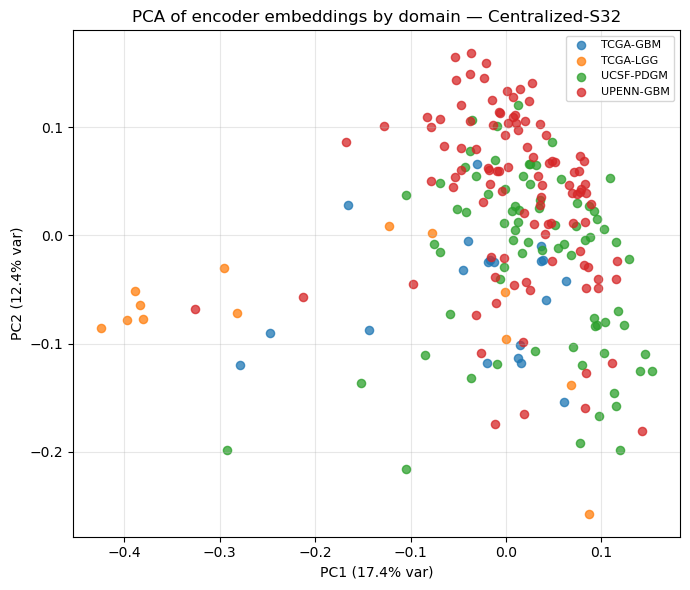

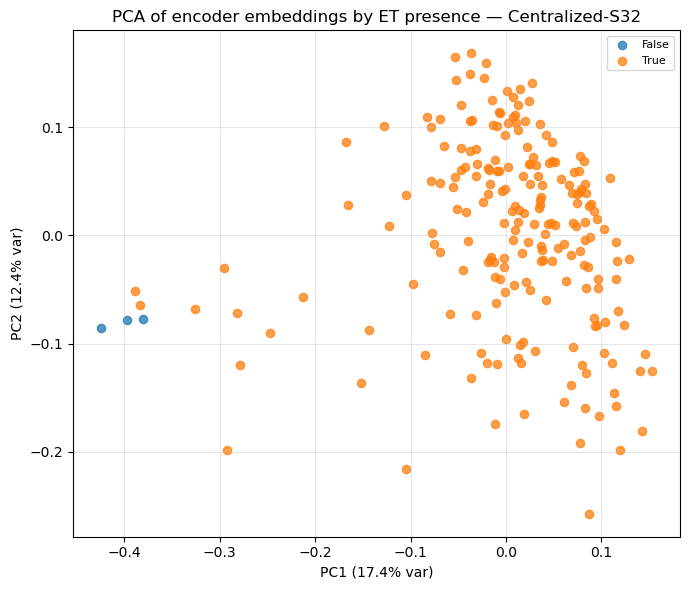

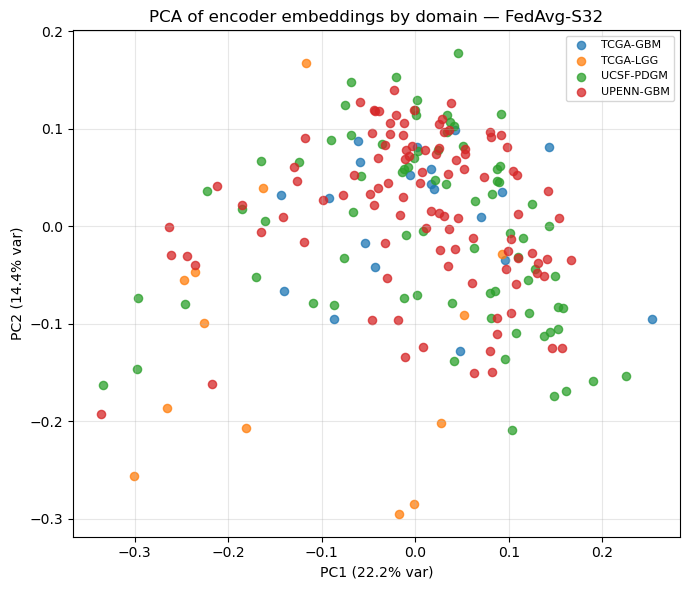

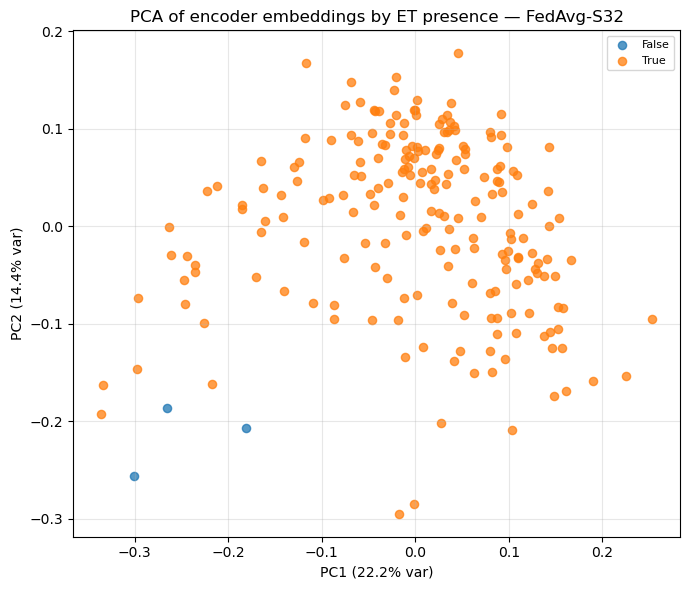

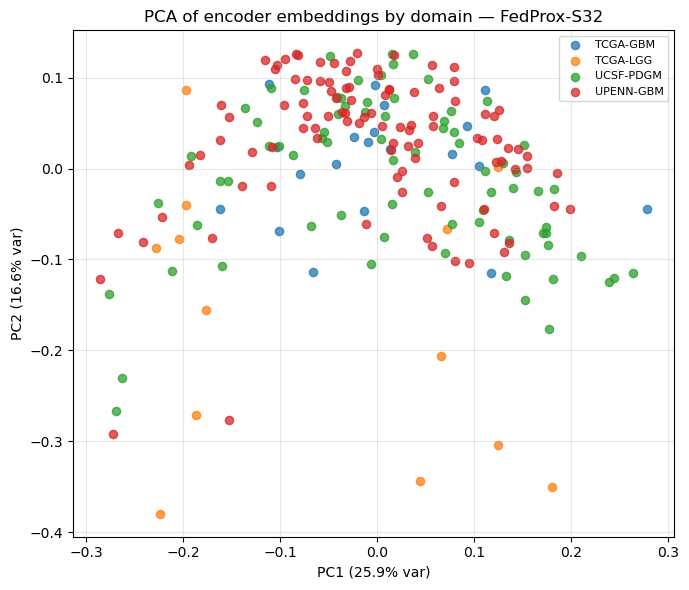

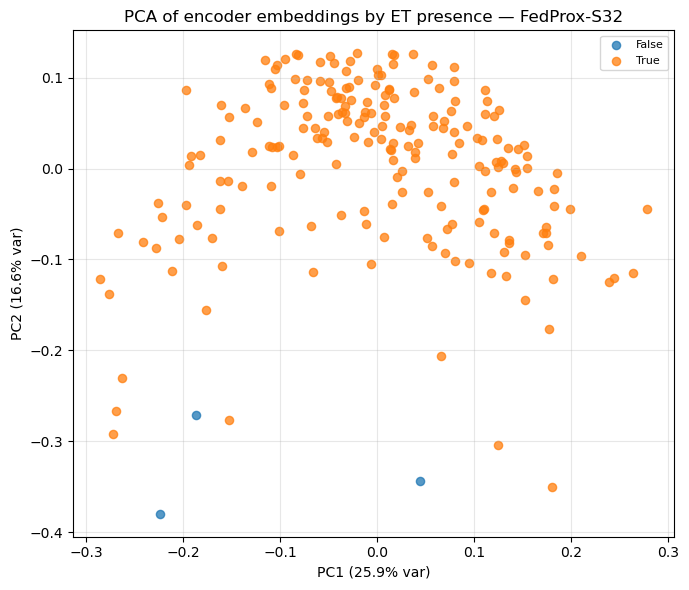

saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/15_pca_figure_paths.csv


In [33]:


def plot_pca_by_group(E, meta_df, group_col, title, save_name):
    """PCA scatter grouped by categorical metadata."""
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(E)

    plot_df = pd.DataFrame({
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "patient_id": meta_df["patient_id"].astype(str).values,
        "group": meta_df[group_col].astype(str).values,
    })

    fig = plt.figure(figsize=(7, 6))
    ax = plt.gca()

    for group, g in plot_df.groupby("group"):
        ax.scatter(g["PC1"], g["PC2"], s=35, alpha=0.75, label=group)

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    png_path = FIGURE_DIR / f"{save_name}.png"
    pdf_path = FIGURE_DIR / f"{save_name}.pdf"
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png_path, pdf_path


if CFG["make_figures"]:
    pca_rows = []

    meta_for_plot = patient_meta.copy()
    meta_for_plot = meta_for_plot.merge(
        features_df[["patient_id", "ET_present"]],
        on="patient_id",
        how="left",
    )
    meta_for_plot["ET_present"] = meta_for_plot["ET_present"].astype(bool).astype(str)

    for key, obj in embeddings_by_exp.items():
        E = obj["E"]
        exp_short = obj["exp"]["short_name"]

        png, pdf = plot_pca_by_group(
            E,
            meta_for_plot,
            group_col="client_domain",
            title=f"PCA of encoder embeddings by domain — {exp_short}",
            save_name=f"pca_domain_{key}",
        )
        pca_rows.append({
            "experiment_key": key,
            "group": "client_domain",
            "png": str(png),
            "pdf": str(pdf)
        })

        png, pdf = plot_pca_by_group(
            E,
            meta_for_plot,
            group_col="ET_present",
            title=f"PCA of encoder embeddings by ET presence — {exp_short}",
            save_name=f"pca_et_presence_{key}",
        )
        pca_rows.append({"experiment_key": key, "group": "ET_present", "png": str(png), "pdf": str(pdf)})

    pca_figures_df = pd.DataFrame(pca_rows)
    save_dataframe(pca_figures_df, "15_pca_figure_paths")

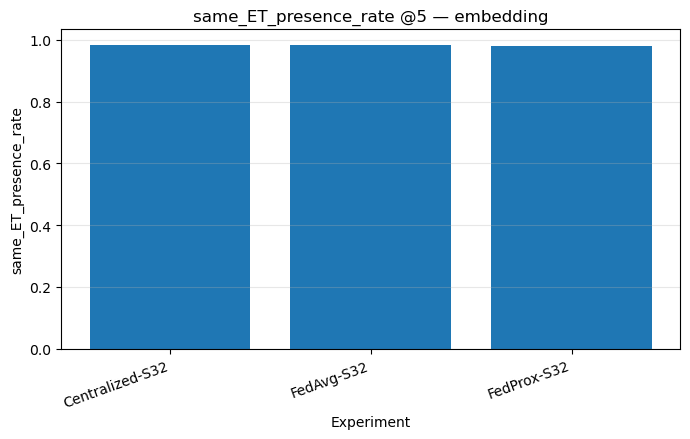

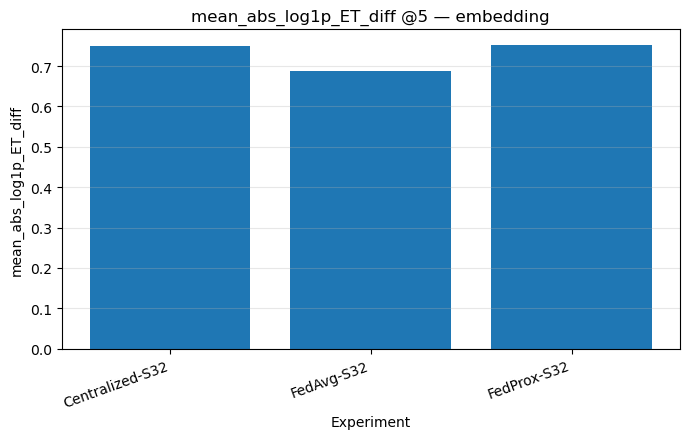

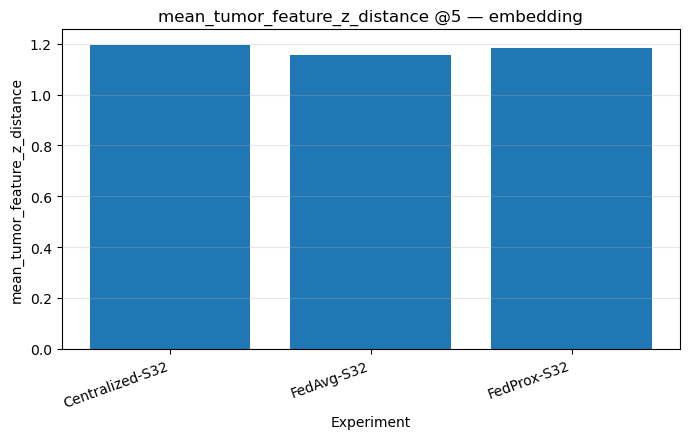

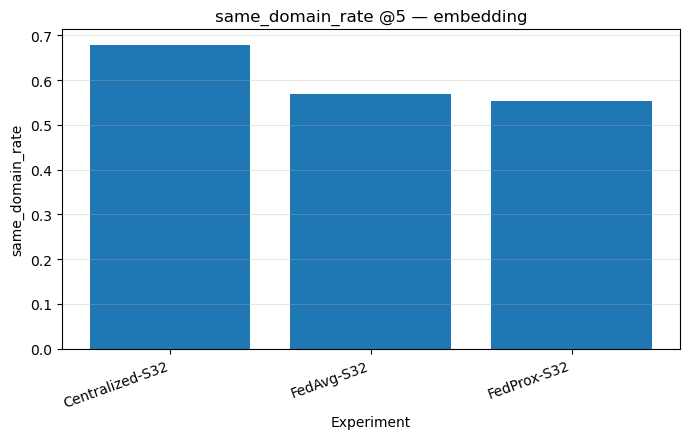

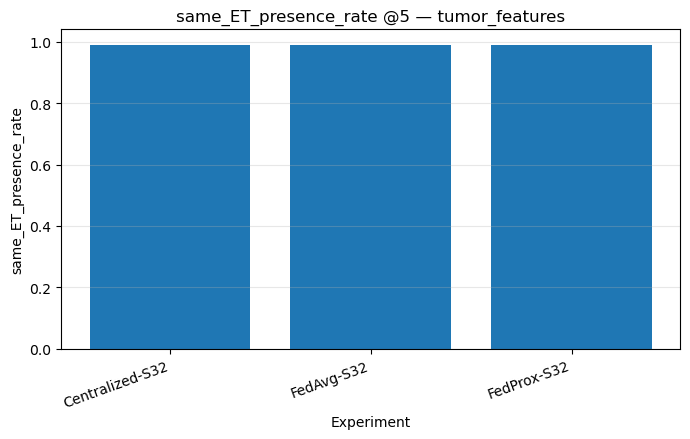

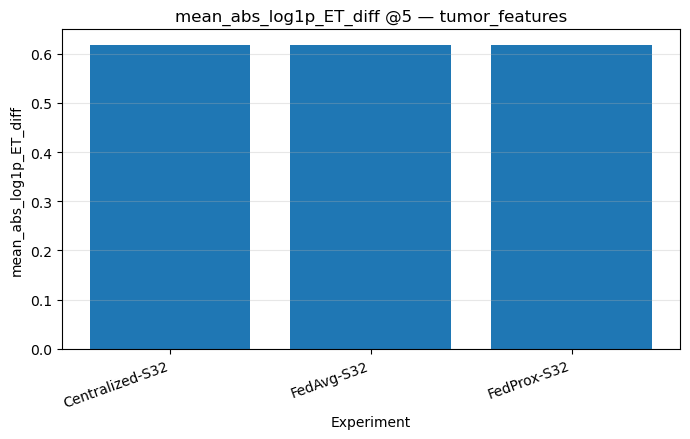

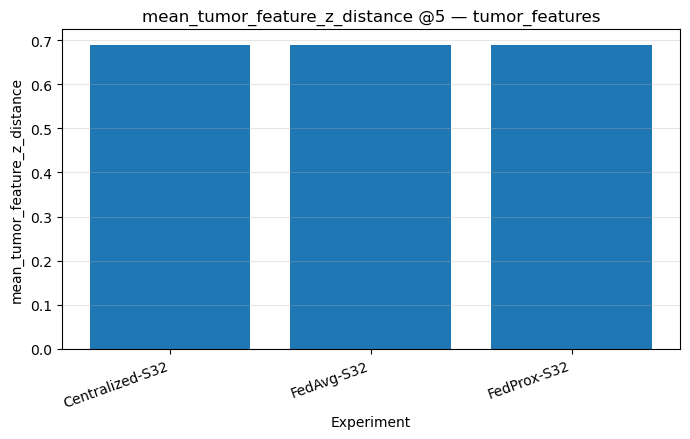

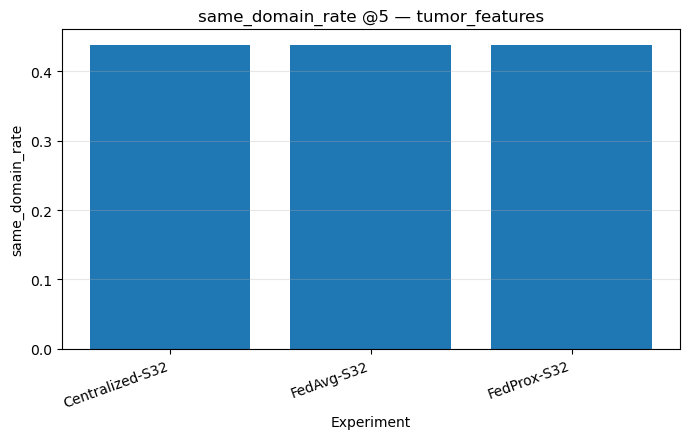

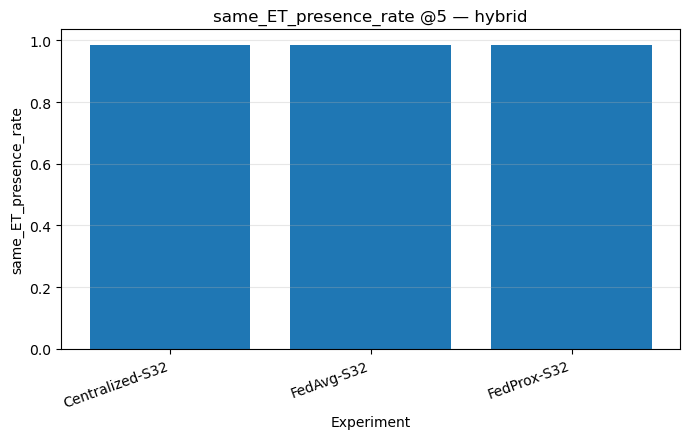

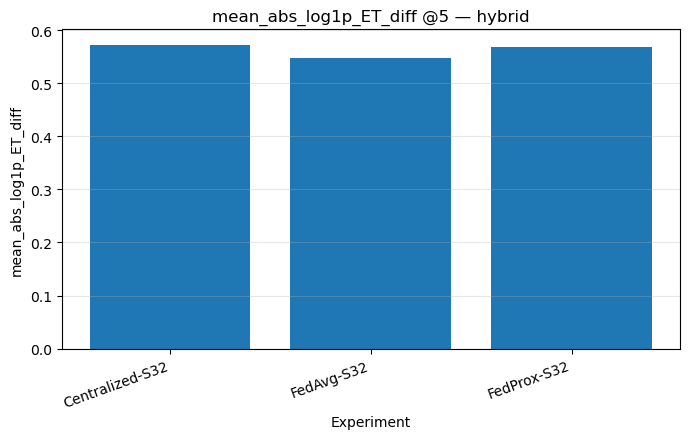

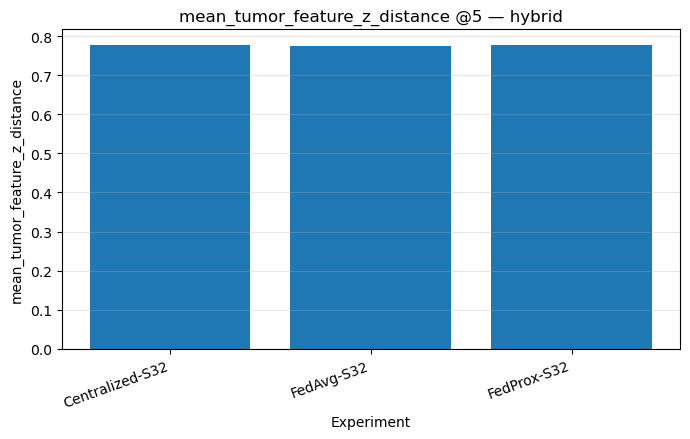

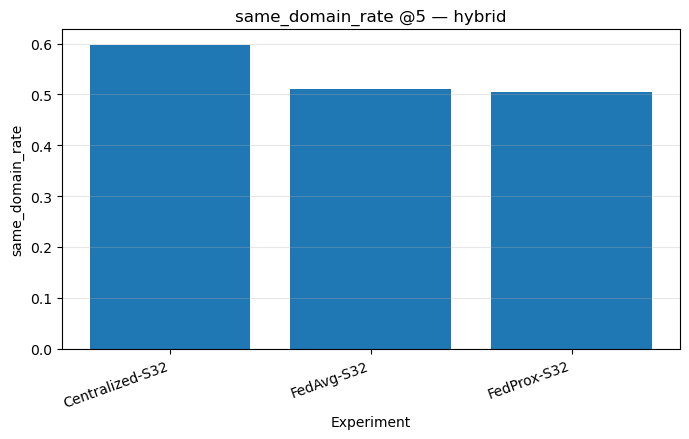

saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/16_retrieval_figure_paths.csv


In [34]:
# 14.1 Retrieval metric figures


def plot_metric_bar(df, metric, k, retrieval_space, title, save_name):
    """Plot one retrieval metric."""
    plot_df = df[
        (df["k"] == k)
        & (df["retrieval_space"] == retrieval_space)
    ].copy()

    if plot_df.empty:
        print("No data for", metric, k, retrieval_space)
        return None, None

    label_map = {exp["key"]: exp["short_name"] for exp in enabled_experiments}
    plot_df["label"] = plot_df["experiment_key"].map(label_map).fillna(plot_df["experiment_key"])

    fig = plt.figure(figsize=(7, 4.5))
    ax = plt.gca()

    ax.bar(plot_df["label"], plot_df[metric])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("Experiment")
    ax.grid(True, axis="y", alpha=0.3)

    plt.xticks(rotation=20, ha="right")
    fig.tight_layout()

    png_path = FIGURE_DIR / f"{save_name}.png"
    pdf_path = FIGURE_DIR / f"{save_name}.pdf"
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png_path, pdf_path


if CFG["make_figures"]:
    fig_rows = []
    plot_k = 5 if 5 in CFG["top_k"] else CFG["top_k"][0]

    for space in CFG["retrieval_spaces"]:
        for metric in [
            "same_ET_presence_rate",
            "mean_abs_log1p_ET_diff",
            "mean_tumor_feature_z_distance",
            "same_domain_rate",
        ]:
            png, pdf = plot_metric_bar(
                overall_metrics_df,
                metric=metric,
                k=plot_k,
                retrieval_space=space,
                title=f"{metric} @{plot_k} — {space}",
                save_name=f"retrieval_{metric}_k{plot_k}_{space}",
            )
            if png is not None:
                fig_rows.append({
                    "retrieval_space": space,
                    "metric": metric,
                    "png": str(png),
                    "pdf": str(pdf),
                })

    retrieval_figures_df = pd.DataFrame(fig_rows)
    save_dataframe(retrieval_figures_df, "16_retrieval_figure_paths")

## Domain leakage and segmentation–retrieval linkage

In [35]:


domain_leakage_df = overall_metrics_df[
    [
        "experiment_key", "retrieval_space", "k",
        "same_domain_rate", "expected_same_domain_rate",
        "same_domain_enrichment", "cross_domain_rate",
    ]
].copy()

safe_display("Domain leakage summary", domain_leakage_df, n=30)
save_dataframe(domain_leakage_df, "17_domain_leakage_summary")

domain_leakage_by_query_domain_df = domain_metrics_df[
    [
        "experiment_key", "retrieval_space", "query_domain", "k",
        "same_domain_rate", "expected_same_domain_rate",
        "same_domain_enrichment", "cross_domain_rate",
    ]
].copy()

safe_display("Domain leakage by query domain", domain_leakage_by_query_domain_df, n=40)
save_dataframe(domain_leakage_by_query_domain_df, "18_domain_leakage_by_query_domain")

### Domain leakage summary

,experiment_key,retrieval_space,k,same_domain_rate,expected_same_domain_rate,same_domain_enrichment,cross_domain_rate
0,centralized_s32_cew,embedding,1,0.758294,0.373234,2.764430,0.241706
1,centralized_s32_cew,embedding,3,0.715640,0.373234,2.624033,0.284360
2,centralized_s32_cew,embedding,5,0.679621,0.373234,2.412256,0.320379
3,centralized_s32_cew,embedding,10,0.643128,0.373234,2.167032,0.356872
4,centralized_s32_cew,hybrid,1,0.649289,0.373234,2.389706,0.350711
5,centralized_s32_cew,hybrid,3,0.609795,0.373234,2.179315,0.390205
6,centralized_s32_cew,hybrid,5,0.598104,0.373234,2.176626,0.401896
7,centralized_s32_cew,hybrid,10,0.554502,0.373234,1.866829,0.445498
8,centralized_s32_cew,tumor_features,1,0.445498,0.373234,1.506571,0.554502
9,centralized_s32_cew,tumor_features,3,0.469194,0.373234,1.594379,0.530806


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/17_domain_leakage_summary.csv


### Domain leakage by query domain

,experiment_key,retrieval_space,query_domain,k,same_domain_rate,expected_same_domain_rate,same_domain_enrichment,cross_domain_rate
0,centralized_s32_cew,embedding,TCGA-GBM,1,0.550000,0.090476,6.078947,0.450000
1,centralized_s32_cew,embedding,TCGA-GBM,3,0.416667,0.090476,4.605263,0.583333
2,centralized_s32_cew,embedding,TCGA-GBM,5,0.340000,0.090476,3.757895,0.660000
3,centralized_s32_cew,embedding,TCGA-GBM,10,0.315000,0.090476,3.481579,0.685000
4,centralized_s32_cew,embedding,TCGA-LGG,1,0.538462,0.057143,9.423077,0.461538
5,centralized_s32_cew,embedding,TCGA-LGG,3,0.615385,0.057143,10.769231,0.384615
6,centralized_s32_cew,embedding,TCGA-LGG,5,0.553846,0.057143,9.692308,0.446154
7,centralized_s32_cew,embedding,TCGA-LGG,10,0.407692,0.057143,7.134615,0.592308
8,centralized_s32_cew,embedding,UCSF-PDGM,1,0.802632,0.357143,2.247368,0.197368
9,centralized_s32_cew,embedding,UCSF-PDGM,3,0.758772,0.357143,2.124561,0.241228


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/18_domain_leakage_by_query_domain.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/18_domain_leakage_by_query_domain.csv')

In [36]:
# 15.1 Join retrieval with segmentation metrics


seg_metric_frames = []

for exp in enabled_experiments:
    key = exp["key"]
    mdf = metrics_by_exp[key].copy()

    keep_cols = [
        "patient_id",
        "dice_WT", "dice_TC", "dice_ET",
        "gt_WT_vox", "gt_TC_vox", "gt_ET_vox",
        "pred_WT_vox", "pred_TC_vox", "pred_ET_vox",
    ]
    keep_cols = [c for c in keep_cols if c in mdf.columns]

    mdf = mdf[keep_cols].copy()
    mdf["experiment_key"] = key
    seg_metric_frames.append(mdf)

seg_metrics_long_df = pd.concat(seg_metric_frames, axis=0, ignore_index=True)

retrieval_plus_seg_df = query_metrics_df.merge(
    seg_metrics_long_df,
    left_on=["experiment_key", "query_patient_id"],
    right_on=["experiment_key", "patient_id"],
    how="left",
)

safe_display("Retrieval metrics joined with segmentation metrics", retrieval_plus_seg_df, n=10)
save_dataframe(retrieval_plus_seg_df, "19_retrieval_plus_segmentation_metrics")

### Retrieval metrics joined with segmentation metrics

,experiment_key,retrieval_space,query_patient_id,query_domain,k,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,...,patient_id,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox
0,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,1,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00003,0.979194,0.977141,0.948207,99239,41466,24252,101428,42133,25349
1,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,3,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00003,0.979194,0.977141,0.948207,99239,41466,24252,101428,42133,25349
2,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,5,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00003,0.979194,0.977141,0.948207,99239,41466,24252,101428,42133,25349
3,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,10,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00003,0.979194,0.977141,0.948207,99239,41466,24252,101428,42133,25349
4,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,1,0.000000,1.000000,0.357143,0.000000,1.0,...,BraTS2021_00009,0.825370,0.932083,0.898392,27453,1865,1480,20099,1654,1256
5,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,3,0.666667,0.333333,0.357143,1.866667,1.0,...,BraTS2021_00009,0.825370,0.932083,0.898392,27453,1865,1480,20099,1654,1256
6,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,5,0.400000,0.600000,0.357143,1.120000,1.0,...,BraTS2021_00009,0.825370,0.932083,0.898392,27453,1865,1480,20099,1654,1256
7,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,10,0.400000,0.600000,0.357143,1.120000,1.0,...,BraTS2021_00009,0.825370,0.932083,0.898392,27453,1865,1480,20099,1654,1256
8,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,1,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00014,0.887734,0.582848,0.578966,38358,2559,2557,42040,6198,6048
9,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,3,1.000000,0.000000,0.357143,2.800000,1.0,...,BraTS2021_00014,0.887734,0.582848,0.578966,38358,2559,2557,42040,6198,6048


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/19_retrieval_plus_segmentation_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/19_retrieval_plus_segmentation_metrics.csv')

In [37]:
# 15.2 Segmentation–retrieval correlation diagnostics


corr_pairs = [
    ("dice_WT", "mean_abs_log1p_WT_diff"),
    ("dice_TC", "mean_abs_log1p_TC_diff"),
    ("dice_ET", "mean_abs_log1p_ET_diff"),
    ("dice_ET", "same_ET_presence_rate"),
    ("dice_ET", "mean_tumor_feature_z_distance"),
]

correlation_rows = []

for (exp_key, space, k), g in retrieval_plus_seg_df.groupby(["experiment_key", "retrieval_space", "k"]):
    for x_col, y_col in corr_pairs:
        if x_col not in g.columns or y_col not in g.columns:
            continue

        sub = g[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        if len(sub) < 3:
            corr = np.nan
        else:
            corr = float(sub[x_col].corr(sub[y_col], method="spearman"))

        correlation_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": k,
            "x_seg_metric": x_col,
            "y_retrieval_metric": y_col,
            "n": len(sub),
            "spearman_corr": corr,
        })

seg_retrieval_corr_df = pd.DataFrame(correlation_rows)
safe_display("Segmentation–retrieval correlation diagnostics", seg_retrieval_corr_df, n=30)
save_dataframe(seg_retrieval_corr_df, "20_segmentation_retrieval_correlation_diagnostics")

/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


### Segmentation–retrieval correlation diagnostics

,experiment_key,retrieval_space,k,x_seg_metric,y_retrieval_metric,n,spearman_corr
0,centralized_s32_cew,embedding,1,dice_WT,mean_abs_log1p_WT_diff,211,-0.133125
1,centralized_s32_cew,embedding,1,dice_TC,mean_abs_log1p_TC_diff,211,-0.173680
2,centralized_s32_cew,embedding,1,dice_ET,mean_abs_log1p_ET_diff,211,-0.242933
3,centralized_s32_cew,embedding,1,dice_ET,same_ET_presence_rate,211,0.193884
4,centralized_s32_cew,embedding,1,dice_ET,mean_tumor_feature_z_distance,211,-0.104172
5,centralized_s32_cew,embedding,3,dice_WT,mean_abs_log1p_WT_diff,211,-0.233784
6,centralized_s32_cew,embedding,3,dice_TC,mean_abs_log1p_TC_diff,211,-0.384141
7,centralized_s32_cew,embedding,3,dice_ET,mean_abs_log1p_ET_diff,211,-0.321230
8,centralized_s32_cew,embedding,3,dice_ET,same_ET_presence_rate,211,0.187709
9,centralized_s32_cew,embedding,3,dice_ET,mean_tumor_feature_z_distance,211,-0.022429


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/20_segmentation_retrieval_correlation_diagnostics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/20_segmentation_retrieval_correlation_diagnostics.csv')

## Retrieval report

In [38]:


def get_metric_value(df, exp_key, space, k, metric):
    sub = df[
        (df["experiment_key"] == exp_key)
        & (df["retrieval_space"] == space)
        & (df["k"] == k)
    ]

    if sub.empty:
        return np.nan

    return float(sub[metric].iloc[0])


report_k = 5 if 5 in CFG["top_k"] else CFG["top_k"][0]
report_space = "embedding"


# Retrieval summary
summary_rows = []

for exp in enabled_experiments:
    key = exp["key"]

    summary_rows.append(
        {
            "Model": exp["name"],
            "ET consistency": get_metric_value(
                overall_metrics_df,
                key,
                report_space,
                report_k,
                "same_ET_presence_rate",
            ),
            "ET volume diff": get_metric_value(
                overall_metrics_df,
                key,
                report_space,
                report_k,
                "mean_abs_log1p_ET_diff",
            ),
            "Tumor z-distance": get_metric_value(
                overall_metrics_df,
                key,
                report_space,
                report_k,
                "mean_tumor_feature_z_distance",
            ),
            "Same-domain rate": get_metric_value(
                overall_metrics_df,
                key,
                report_space,
                report_k,
                "same_domain_rate",
            ),
            "Same-domain enrichment": get_metric_value(
                overall_metrics_df,
                key,
                report_space,
                report_k,
                "same_domain_enrichment",
            ),
        }
    )

retrieval_summary_df = pd.DataFrame(summary_rows)


# Dataset summary
domain_counts_df = (
    eval_df.groupby("client_domain")
    .size()
    .reset_index(name="n")
    .rename(
        columns={
            "client_domain": "Domain",
            "n": "Patients",
        }
    )
)


# Experiment summary
experiment_summary_df = pd.DataFrame(
    [
        {
            "Key": exp["key"],
            "Model": exp["name"],
        }
        for exp in enabled_experiments
    ]
)


report_parts = [
    "# 08 Static Digital Twin Retrieval Report",
    "",
    "## Evaluation setup",
    "",
    f"- Manifest: `{manifest_path}`",
    f"- Split: `{CFG['split_filter']}`",
    f"- Patients: `{len(eval_df)}`",
    f"- ROI source: `{CFG['roi_source']}`",
    f"- Patch size: `{CFG['patch_size']}`",
    f"- Embedding method: `{CFG['embedding_method']}`",
    f"- Retrieval spaces: `{CFG['retrieval_spaces']}`",
    f"- Top-k: `{CFG['top_k']}`",
    "",
    "## Domain counts",
    "",
    domain_counts_df.to_markdown(index=False),
    "",
    "## Experiments",
    "",
    experiment_summary_df.to_markdown(index=False),
    "",
    f"## Encoder embedding retrieval at k={report_k}",
    "",
    retrieval_summary_df.round(4).to_markdown(index=False),
    "",
]


if CFG["roi_source"] == "gt_wt_center":
    report_parts.extend(
        [
            "## Evaluation note",
            "",
            (
                "ROI localization uses the ground-truth WT center. "
                "This analysis therefore represents the GT-centered "
                "upper-bound retrieval setting rather than the primary "
                "predicted-mask ROI pipeline."
            ),
            "",
        ]
    )


report_parts.extend(
    [
        "## Metric notes",
        "",
        (
            "- `embedding` evaluates nearest-neighbor retrieval in the "
            "segmentation-trained encoder representation."
        ),
        (
            "- `tumor_features` is a phenotype-feature retrieval baseline "
            "and is not a learned embedding."
        ),
        (
            "- `hybrid` combines representation and tumor-feature information "
            "and is reported separately."
        ),
        (
            "- Same-domain rate and enrichment describe domain clustering; "
            "they are not retrieval-quality metrics by themselves."
        ),
        "",
        "## Outputs",
        "",
        f"- Tables: `{TABLE_DIR}`",
        f"- Embeddings: `{EMBED_DIR}`",
        f"- Figures: `{FIGURE_DIR}`",
        f"- Reports: `{REPORT_DIR}`",
        "",
    ]
)


report_text = "\n".join(report_parts)

report_path = (
    REPORT_DIR
    / "08_static_digital_twin_retrieval_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

display(Markdown(report_text))
print("saved report:", report_path)

# 08 Static Digital Twin Retrieval Report

## Evaluation setup

- Manifest: `/home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv`
- Split: `['test']`
- Patients: `211`
- ROI source: `gt_wt_center`
- Patch size: `(128, 128, 128)`
- Embedding method: `multiscale_gap_gmp`
- Retrieval spaces: `['embedding', 'tumor_features', 'hybrid']`
- Top-k: `[1, 3, 5, 10]`

## Domain counts

| Domain    |   Patients |
|:----------|-----------:|
| TCGA-GBM  |         20 |
| TCGA-LGG  |         13 |
| UCSF-PDGM |         76 |
| UPENN-GBM |        102 |

## Experiments

| Key                 | Model                                            |
|:--------------------|:-------------------------------------------------|
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      |
| fedprox_s32_cew     | FedProx SegResNet32 final CE-weighted — TEST     |

## Encoder embedding retrieval at k=5

| Model                                            |   ET consistency |   ET volume diff |   Tumor z-distance |   Same-domain rate |   Same-domain enrichment |
|:-------------------------------------------------|-----------------:|-----------------:|-------------------:|-------------------:|-------------------------:|
| Centralized SegResNet32 final CE-weighted — TEST |           0.9848 |           0.7504 |             1.1972 |             0.6796 |                   2.4123 |
| FedAvg SegResNet32 final CE-weighted — TEST      |           0.9848 |           0.6867 |             1.1566 |             0.5697 |                   1.7595 |
| FedProx SegResNet32 final CE-weighted — TEST     |           0.981  |           0.7533 |             1.1845 |             0.5545 |                   1.7269 |

## Evaluation note

ROI localization uses the ground-truth WT center. This analysis therefore represents the GT-centered upper-bound retrieval setting rather than the primary predicted-mask ROI pipeline.

## Metric notes

- `embedding` evaluates nearest-neighbor retrieval in the segmentation-trained encoder representation.
- `tumor_features` is a phenotype-feature retrieval baseline and is not a learned embedding.
- `hybrid` combines representation and tumor-feature information and is reported separately.
- Same-domain rate and enrichment describe domain clustering; they are not retrieval-quality metrics by themselves.

## Outputs

- Tables: `/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables`
- Embeddings: `/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/embeddings`
- Figures: `/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/figures`
- Reports: `/home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/reports`


saved report: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/reports/08_static_digital_twin_retrieval_report.md


## Notes

GT-centered ROIs provide an oracle-localization reference. Domain clustering is reported as a diagnostic; phenotype-distance comparisons are evaluated against matched random controls in notebook 08b.

## Run manifest and output checks

In [40]:


run_manifest = {
    "notebook": "08_embedding_static_digital_twin_retrieval",
    "project_root": str(PROJECT_ROOT),
    "save_dir": str(SAVE_DIR),
    "manifest": str(manifest_path),
    "cfg": CFG,
    "n_eval_patients": int(len(eval_df)),
    "experiments": [
        {
            "key": exp["key"],
            "name": exp["name"],
            "checkpoint": str(exp["checkpoint_resolved"]),
            "metrics": str(exp["metrics_path_resolved"]),
        }
        for exp in enabled_experiments
    ],
    "outputs": {
        "tables": str(TABLE_DIR),
        "embeddings": str(EMBED_DIR),
        "figures": str(FIGURE_DIR),
        "reports": str(REPORT_DIR),
    },
}

run_manifest_path = LOG_DIR / "08_run_manifest.json"

run_manifest_path.write_text(
    json.dumps(run_manifest, indent=2, default=str),
    encoding="utf-8",
)


checks = {
    "features_complete": len(features_df) == len(eval_df),
    "embeddings_complete": (
        len(embeddings_by_exp) == len(enabled_experiments)
    ),
    "embedding_integrity": bool(
        integrity_df["all_finite"].all()
        and integrity_df["patient_order_aligned"].all()
    ),
    "neighbors_available": not neighbors_df.empty,
    "overall_metrics_available": not overall_metrics_df.empty,
    "domain_metrics_available": not domain_metrics_df.empty,
    "report_saved": report_path.exists(),
}

checks["complete"] = all(checks.values())

checks_df = pd.DataFrame([checks])

safe_display(
    "Run validation",
    checks_df,
)

save_dataframe(
    checks_df,
    "21_output_checks",
)


if checks["complete"]:
    display(
        Markdown(
            "**PASS:** GT-centered TEST retrieval outputs are complete."
        )
    )
else:
    failed = [
        name
        for name, passed in checks.items()
        if name != "complete" and not passed
    ]

    display(
        Markdown(
            "**FAIL:** incomplete outputs: "
            + ", ".join(f"`{name}`" for name in failed)
        )
    )


print("saved run manifest:", run_manifest_path)

### Run validation

,features_complete,embeddings_complete,embedding_integrity,neighbors_available,overall_metrics_available,domain_metrics_available,report_saved,complete
0,True,True,True,True,True,True,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/tables/21_output_checks.csv


**PASS:** GT-centered TEST retrieval outputs are complete.

saved run manifest: /home/mandrakedrink/projects/research_ts_bs/docs/08_static_digital_twin_retrieval_test/logs/08_run_manifest.json
